In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('product_info.csv')

# View first rows
df.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price,Nivel de Precio,Vale la Pena?
0,P409800,Cleansing & Exfoliating Wipes,3902,SEPHORA COLLECTION,266116,4.3383,3837.0,10 Wipes,Type,NaN,...,1,"['Clean at Sephora', 'Good for: Dryness', 'Bes...",Skincare,Cleansers,Face Wipes,1,3.0,3.0,Accesible,Normal
1,P460703,Organic Cotton Swabs,3902,SEPHORA COLLECTION,21081,4.4624,93.0,200 Swabs,Size,200 Swabs,...,1,"['Vegan', 'Clean + Planet Positive']",Makeup,Accessories,Makeup Removers,0,NaN,NaN,Accesible,Normal
2,P461522,Clean Charcoal Nose Strip,3902,SEPHORA COLLECTION,25388,3.0273,183.0,1 Mask,Size,1 Mask,...,1,"['Vegan', 'Good for: Pores', 'Clean at Sephora...",Skincare,Masks,Sheet Masks,0,NaN,NaN,Accesible,Normal
3,P460724,Mini Clean Cleansing & Gentle Exfoliating Wipes,3902,SEPHORA COLLECTION,6569,3.1961,51.0,10 Wipes,Type,NaN,...,0,"['Vegan', 'Clean at Sephora']",Mini Size,Skincare,NaN,0,NaN,NaN,Accesible,Normal
4,P444237,Mini Cleansing Wipes - Coconut Water,3902,SEPHORA COLLECTION,265,4.3000,10.0,10 Wipes,Type,NaN,...,1,"['Clean at Sephora', 'Good for: Dryness', 'Bes...",Skincare,Cleansers,Face Wipes,0,NaN,NaN,Accesible,Normal


In [12]:
# Dataset shape and basic info
print(f"Total products: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print("\n--- Missing values ---")
print(df.isnull().sum())

Total products: 8494
Total columns: 29

--- Missing values ---
product_id               0
product_name             0
brand_id                 0
brand_name               0
loves_count              0
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
price_usd                0
value_price_usd       8043
sale_price_usd        8224
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
tertiary_category      990
child_count              0
child_max_price       5740
child_min_price       5740
Nivel de Precio          0
Vale la Pena?            0
dtype: int64


In [13]:
# Data Cleaning
# Remove rows without rating (essential for analysis)
df_clean = df.dropna(subset=['rating', 'reviews'])

print(f"Original dataset: {df.shape[0]} products")
print(f"Clean dataset: {df_clean.shape[0]} products")
print(f"Removed: {df.shape[0] - df_clean.shape[0]} products without rating")

# Confirm no missing values in key columns
print("\n--- Key columns after cleaning ---")
print(df_clean[['brand_name','price_usd','rating','reviews']].isnull().sum())

Original dataset: 8494 products
Clean dataset: 8216 products
Removed: 278 products without rating

--- Key columns after cleaning ---
brand_name    0
price_usd     0
rating        0
reviews       0
dtype: int64


In [14]:
# Quality-Price Analysis
# Best value brands: high rating + affordable price

brand_analysis = df_clean.groupby('brand_name').agg(
    avg_price=('price_usd', 'mean'),
    avg_rating=('rating', 'mean'),
    total_products=('product_id', 'count')
).reset_index()

# Filter brands with at least 5 products
brand_analysis = brand_analysis[brand_analysis['total_products'] >= 5]

# Top 10 best value (highest rating, lowest price)
brand_analysis['value_score'] = brand_analysis['avg_rating'] / brand_analysis['avg_price']
top_value = brand_analysis.nlargest(10, 'value_score')

print("Top 10 Best Value Brands:")
print(top_value[['brand_name','avg_price','avg_rating','value_score']].round(2))

Top 10 Best Value Brands:
                       brand_name  avg_price  avg_rating  value_score
217           Rosebud Perfume Co.       7.50        4.39         0.59
254                  The Ordinary      12.43        4.11         0.33
252                The INKEY List      13.55        4.08         0.30
119                   INC.redible      12.93        3.69         0.29
219            SEPHORA COLLECTION      16.39        4.08         0.25
152                    LYS Beauty      18.67        4.46         0.24
197  PATTERN by Tracee Ellis Ross      18.34        4.26         0.23
255    The Original MakeUp Eraser      19.71        4.45         0.23
177                    NAILS INC.      17.06        3.82         0.22
167                 Mario Badescu      17.70        3.94         0.22


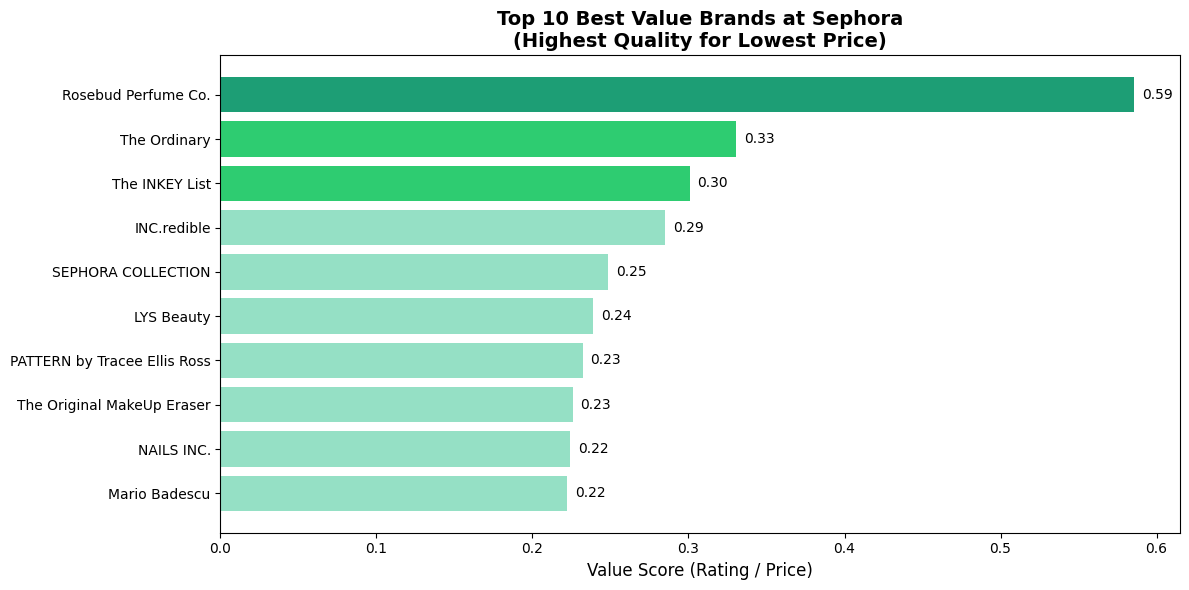

Chart saved!


In [15]:
# Visualization - Top 10 Best Value Brands
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1D9E75' if i == 0 else '#2ECC71' if i < 3 else '#95E0C5'
          for i in range(len(top_value))]

bars = ax.barh(top_value['brand_name'], top_value['value_score'], color=colors)

ax.set_xlabel('Value Score (Rating / Price)', fontsize=12)
ax.set_title('Top 10 Best Value Brands at Sephora\n(Highest Quality for Lowest Price)',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, top_value['value_score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('best_value_brands_sephora.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")